**오늘의 학습 목표**
- LangGraph를 이용한 RAG 워크플로우 구성 및 Context 기반 답변 생성 구조 이해
- 출처 출력하는 RAG 워크플로우 구축해보기

**학습 날짜**
- 2026.05.24, 05.30 (수술때매 퇴근 후 공부를 할 수 없었다...ㅜㅜ)

#### 01. RAG 시스템 구현을 위한 문서 수집, 청킹, 임베딩 및 벡터 DB 구축

In [8]:
# 01. 모델 선언하기

from langchain.chat_models import init_chat_model
llm = init_chat_model("gemma3:4b", model_provider="ollama")

In [9]:
# 02. 텍스트 추출 및 청킹

from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_ollama import ChatOllama, OllamaEmbeddings
from langchain_qdrant import qdrant
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough

loader = PyPDFLoader(
    file_path="data/PIKC.pdf",
)
docs = loader.load()

text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
splits = text_splitter.split_documents(docs)

print(splits[0].page_content)

IEEE SENSORS JOURNAL, VOL. 23, NO. 18, 15 SEPTEMBER 2023 21397
Classification Network-Guided Weighted
K-Means Clustering for Multitouch Detection
James Lee, Jun-Ha Yun, Jae-Hun Shim
 , and Suk-Ju Kang
 ,Member, IEEE
Abstract —In mobile devices, multitouch recognition tech-
nology is utilized to interact with the touch screen. Recogniz-
ing the coordinates of finger touches is the most important
task in multitouch recognition. Several studies have been
conducted to detect touch coordinates. However, these stud-
ies have been unable to detect exact coordinates when
the big-finger problem occurs. The big-finger problem is a
phenomenon in which a hole is generated in the center of
the touch area when a large object approaches the touch
screen, and it becomes more serious in a low-ground-mass
environment. To solve the big-finger problem, we propose a
novel method that detects touch coordinates using the clus-
tering algorithm. We perform clustering on the touch data by


In [10]:
# 03. Ollama 통한 임베딩 모델 로드

from langchain_ollama import OllamaEmbeddings
embeddings = OllamaEmbeddings(model="bge-m3")

In [12]:
# 04. Qdrant 벡터DB 저장 및 검색기 설정

from langchain_qdrant import QdrantVectorStore, RetrievalMode
from qdrant_client import QdrantClient
from qdrant_client.http.models import Distance, VectorParams
from uuid import uuid4

# Qdrant 저장 공간 생성/연결
client = QdrantClient(path="/tmp/0530/PIKC")

# 벡터 저장할 테이블 생성
client.create_collection(
    collection_name="PIKCagent_0530",
    vectors_config=VectorParams(size=1024, distance=Distance.COSINE),
)

# LangChain이 client를 이용해서 문서 넣고 검색 가능하게 연결
qdrant = QdrantVectorStore(
    client=client,
    collection_name="PIKCagent_0530",
    embedding=embeddings,
    retrieval_mode=RetrievalMode.DENSE,
)

uuids = [str(uuid4()) for _ in range(len(splits))]

qdrant.add_documents(documents=splits, ids=uuids)

['9eee9fed-226e-4ae9-802f-4e976ae512e9',
 '51a8eb03-a36d-46b7-81fc-68dbc6b981ba',
 '7d6ead24-2ca3-442e-a654-1d33a4727951',
 '880183ff-e8e9-4fe5-b3e7-1f9bf16e6ee0',
 'ccb39c4b-4265-41f8-baa3-ba5356500ddc',
 '0870a19e-cef8-45d4-96bb-7d023db8d96c',
 '10c02bb9-3d09-4a7a-929c-62d7894a2ef8',
 '62194073-3640-4050-aabf-df8a14810d82',
 '53ba631b-c93d-4f31-8fe7-0029e367509a',
 '1fbfd0e7-c979-4694-b565-40e4301d2e50',
 'bd956346-af58-4334-8f49-9d4ea55cd0e8',
 '65d03b33-5b14-4f20-a537-d1f00deffe44',
 '50e4e046-7f3d-42b2-a02f-a265dbc3995e',
 '266a32c1-b6bd-4473-9e34-dd83ddd11389',
 '55c46c24-f34d-4b0b-9b16-e4212df06131',
 'fb5ea69a-cf71-4852-9aab-84ae68c85389',
 'e2b70d5b-f887-41cb-9e5e-bf90b84dc76b',
 'e67e6d98-2e51-4c1a-9c5f-7d2dc076b180',
 '06d24963-6ef3-4eb0-ab9d-600492a64c4c',
 '7f8a6dd7-ce88-419e-a4fb-7d3876b7626b',
 '03d81d34-a3dd-494c-bd88-fcddb7ee0be9',
 'a0f6899f-a742-4837-97e0-bf2b65600ca3',
 '7fe894c1-b0c3-45f0-8002-e10555684503',
 '942897d0-dcd3-4a20-94d7-915ac49a8fbe',
 '6a925500-443d-

In [13]:
retriever = qdrant.as_retriever() # 벡터 저장소를 검색기로 설정

search_result=retriever.invoke("Big finger problem이 뭐야?")

for doc in search_result:
    print(doc.page_content[:500])
    print(doc.metadata)
    print("-"*100)

21398 IEEE SENSORS JOURNAL, VOL. 23, NO. 18, 15 SEPTEMBER 2023
Fig. 1. Touch signal with a large area of touch causes the big-finger
problem that generates holes at the center of the touch.
the touch coordinates with the topmost pixel in the generated
touch mask.
Recent studies have utilized deep-learning technology for
performance improvement in touch coordinate detection [17],
[18], [19]. Yoon et al. [17] used a convolutional neural network
(CNN) to classify the number of touches generated on 
{'producer': 'pdfTeX-1.40.24; modified using iText® Core 7.2.4 (AGPL version) ©2000-2022 iText Group NV', 'creator': 'LaTeX with hyperref', 'creationdate': '2023-09-01T21:22:59+05:30', 'moddate': '2023-09-13T14:37:35-04:00', 'ieee article id': '10179190', 'trapped': 'False', 'ieee issue id': '10251409', 'subject': 'IEEE Sensors Journal;2023;23;18;10.1109/JSEN.2023.3292288', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.24 (TeX Live 2022) kpathsea version 6.3.4', 'ieee publica

#### 02. LangGraph를 이용한 RAG 워크플로우 구성 및 Context 기반 답변 생성 구조 이해

##### Langgraph State, node, edge 선언하기

<전체 로직>
1) 사용자 질문    
2) retrieve 노드: 관련 문서 검색  
3) generate 노드: 검색 문서를 바탕으로 LLM 답변 생성    
4) 최종 answer 반환  

<상세 설명>
1. State란?
- 그래프 안에서 들고 다니는 데이터 상자  
- 그래프가 실행되는 동안 공유하는 상태값  
- 노드들 사이에서 전달되는 공용 딕셔너리 구조  

2. 예시  
- 질문 실행  
        ``` python
        {  
            "question": "touch 신호 이상 원인이 뭐야?"  
        }  
        ```
  
- retrieve 실행  
        ``` python
        {  
            "question": "...",  
            "context": [Document(...), Document(...)]  
        }  
        ```
- generate 실행  
        ``` python
        {  
            "question": "...",  
            "context": [...],  
            "answer": "검색된 문서를 보면 ..."  
        }  
        ```

In [14]:
from langgraph.graph import START, StateGraph
from typing_extensions import List, TypedDict
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

# generate 단계에서 필요 : prompt가 없으면 LLM은 검색된 문서를 받아도 어떻게 답해야 할지 모름
prompt = ChatPromptTemplate.from_template("""
당신은 touch 신호 관련 전문가입니다. 질문에 맞는 답변을 해주세요.

컨텍스트:
{context}

질문:
{question}

답변:
""")

class State(TypedDict):
    question: str 
    context: List[Document]
    answer: str


def retrieve(state: State): # 힌트 문장 검색 과정 (state는 위의 state 받아옴)
    retrieved_docs = retriever.invoke(state["question"])
    return {"context": retrieved_docs}

def generate(state: State): # 답변 생성
    docs_content = "\n\n".join(doc.page_content for doc in state["context"]) # Document 객체 그대로 넘기기보다, 문서 안의 텍스트만 뽑아서 넘기는 게 좋음
    messages = prompt.invoke({"question": state["question"], "context": docs_content})
    response = llm.invoke(messages)
    return {"answer": response.content}


# 그래프 조합 (retrieve 노드 -> generate 노드로 흐른다는 뜻)
# 일직선상 구조기 때문에 add_sequence로 간단하게 구현
graph_builder = StateGraph(State).add_sequence([retrieve, generate])
graph_builder.add_edge(START, "retrieve")
graph = graph_builder.compile()

In [15]:
# 답변 보여주기
for message, metadata in graph.stream(
    {"question": "Big Finger Problem이 뭐야?"}, stream_mode="messages"
):
    print(message.content, end="")

Big Finger Problem은 멀티 터치 스크린에 큰 물체가 접근할 때 발생하는 문제로, 터치 영역의 중앙에 구멍이 생겨 정확한 터치 좌표를 감지하지 못하게 됩니다. 특히 접지 연결이 없는 (low ground mass, LGM) 환경에서 심화되는 현상입니다. 즉, 터치 영역이 배경과 명확하게 분리되지 않아 중앙 영역이 무시되기 때문에 좌표 감지 오류가 발생하는 것이죠.


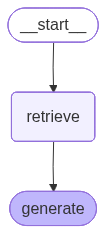

In [7]:
# 어떻게 그래프가 생겼는지 보여주는 것
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

#### 03. 출처 제공하는 LangGraph 구축
- gpt에서 환각현상 검증 등 검증 필요할 때 출처 검출 필요

In [17]:
from typing import List

from typing_extensions import Annotated, TypedDict
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

prompt = ChatPromptTemplate.from_template("""
당신은 touch 신호 관련 전문가입니다. 질문에 맞는 답변을 해주세요.

컨텍스트:
{context}

질문:
{question}

답변:
""")

# Desired schema for response
class AnswerWithSources(TypedDict):
    """An answer to the question, with sources."""

    answer: str
    sources: Annotated[
        List[str],
        ...,
        # 프롬프트로 위치 확인
        "List of sources (title + page number + year ) used to answer the question",
    ]


class State(TypedDict):
    question: str
    context: List[Document]
    answer: AnswerWithSources


def generate(state: State):
    # metadata랑 content를 튜플 형식으로 받아 주석 확인
    docs_content = "\n\n".join(str((doc.metadata,doc.page_content)) for doc in state["context"])
    messages = prompt.invoke({"question": state["question"], "context": docs_content})
    llm = ChatOpenAI(model="gpt-4.1", temperature=0)
    structured_llm = llm.with_structured_output(AnswerWithSources)
    response = structured_llm.invoke(messages)
    return {"answer": response}


graph_builder = StateGraph(State).add_sequence([retrieve, generate])
graph_builder.add_edge(START, "retrieve")
graph = graph_builder.compile()

In [18]:
import json

result = graph.invoke({"question": "Big Finger Problem이 뭐야?"})
result

{'question': 'Big Finger Problem이 뭐야?',
 'context': [Document(metadata={'producer': 'pdfTeX-1.40.24; modified using iText® Core 7.2.4 (AGPL version) ©2000-2022 iText Group NV', 'creator': 'LaTeX with hyperref', 'creationdate': '2023-09-01T21:22:59+05:30', 'moddate': '2023-09-13T14:37:35-04:00', 'ieee article id': '10179190', 'trapped': 'False', 'ieee issue id': '10251409', 'subject': 'IEEE Sensors Journal;2023;23;18;10.1109/JSEN.2023.3292288', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.24 (TeX Live 2022) kpathsea version 6.3.4', 'ieee publication id': '7361', 'title': 'Classification Network-Guided Weighted <italic>K</italic>-Means Clustering for Multitouch Detection', 'source': 'data/PIKC.pdf', 'total_pages': 11, 'page': 1, 'page_label': '21398', '_id': '62194073-3640-4050-aabf-df8a14810d82', '_collection_name': 'PIKCagent_0530'}, page_content='21398 IEEE SENSORS JOURNAL, VOL. 23, NO. 18, 15 SEPTEMBER 2023\nFig. 1. Touch signal with a large area of touch causes t

공부 끝!